# Other Shallow Parsing Baselines (Probabilistic + Neural)

This notebook provides additional baseline methods for CoNLL-2000 chunking:

1. **Multinomial Naive Bayes** (probabilistic token classifier)
2. **Logistic Regression** (strong sparse-feature baseline)
3. **BiLSTM Token Tagger** (neural baseline)
4. **Optional CRF** if `sklearn-crfsuite` is available

Each model is evaluated with token-level and chunk-level metrics.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")

/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load CoNLL-2000 parquet files
DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.parquet"
TEST_PATH = DATA_DIR / "test.parquet"

def read_parquet_safe(path):
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception:
            pass
    raise RuntimeError(f"Could not read {path}")

train_df = read_parquet_safe(TRAIN_PATH)
test_df = read_parquet_safe(TEST_PATH)

CHUNK_LABELS = [
    "O", "B-ADJP", "I-ADJP", "B-ADVP", "I-ADVP", "B-CONJP", "I-CONJP", "B-INTJ", "I-INTJ", "B-LST",
    "I-LST", "B-NP", "I-NP", "B-PP", "I-PP", "B-PRT", "I-PRT", "B-SBAR", "I-SBAR", "B-UCP", "I-UCP",
    "B-VP", "I-VP"
]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (8937, 4)
Test shape: (2013, 4)


In [3]:
# Shared metric helpers
seqeval = evaluate.load("seqeval")

def token_metrics(y_true, y_pred):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return {
        "token_accuracy": float(acc),
        "token_precision_macro": float(p_macro),
        "token_recall_macro": float(r_macro),
        "token_f1_macro": float(f1_macro),
        "token_precision_weighted": float(p_weighted),
        "token_recall_weighted": float(r_weighted),
        "token_f1_weighted": float(f1_weighted),
    }

def seqeval_metrics_from_flat(y_true_flat, y_pred_flat, sentence_lengths):
    y_true_seq, y_pred_seq = [], []
    cursor = 0
    for n in sentence_lengths:
        t = y_true_flat[cursor:cursor+n]
        p = y_pred_flat[cursor:cursor+n]
        y_true_seq.append([CHUNK_LABELS[int(x)] for x in t])
        y_pred_seq.append([CHUNK_LABELS[int(x)] for x in p])
        cursor += n

    out = seqeval.compute(predictions=y_pred_seq, references=y_true_seq)
    return {
        "chunk_precision": float(out["overall_precision"]),
        "chunk_recall": float(out["overall_recall"]),
        "chunk_f1": float(out["overall_f1"]),
        "chunk_accuracy": float(out["overall_accuracy"]),
    }

In [6]:
# Build sparse-feature datasets for probabilistic/discriminative token classifiers
def token_features(tokens, pos_tags, i):
    # Use categorical string features so MultinomialNB receives non-negative values.
    prev_pos = f"POS_{int(pos_tags[i-1])}" if i > 0 else "BOS"
    next_pos = f"POS_{int(pos_tags[i+1])}" if i < len(pos_tags)-1 else "EOS"
    return {
        "tok": tokens[i].lower(),
        "pos": f"POS_{int(pos_tags[i])}",
        "prev_pos": prev_pos,
        "next_pos": next_pos,
        "is_upper": str(tokens[i].isupper()),
        "is_title": str(tokens[i].istitle()),
        "is_digit": str(tokens[i].isdigit()),
    }

def flatten_for_token_models(df):
    X_dict, y, sent_lens = [], [], []
    for _, row in df.iterrows():
        tokens, pos_tags, chunk_tags = row["tokens"], row["pos_tags"], row["chunk_tags"]
        sent_lens.append(len(tokens))
        for i in range(len(tokens)):
            X_dict.append(token_features(tokens, pos_tags, i))
            y.append(int(chunk_tags[i]))
    return X_dict, y, sent_lens

X_train_dict, y_train, _ = flatten_for_token_models(train_df)
X_test_dict, y_test, test_sentence_lengths = flatten_for_token_models(test_df)

vec = DictVectorizer(sparse=True)
X_train = vec.fit_transform(X_train_dict)
X_test = vec.transform(X_test_dict)

print("Train tokens:", len(y_train), "Test tokens:", len(y_test))
print("Minimum value in feature matrix:", X_train.min())

Train tokens: 211727 Test tokens: 47377
Minimum value in feature matrix: 0.0


In [7]:
# Model 1: Multinomial Naive Bayes (probabilistic baseline)
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

nb_results = {}
nb_results.update(token_metrics(y_test, y_pred_nb))
nb_results.update(seqeval_metrics_from_flat(y_test, y_pred_nb, test_sentence_lengths))

print(json.dumps(nb_results, indent=2))

/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{
  "token_accuracy": 0.9167106401840556,
  "token_precision_macro": 0.488975911334832,
  "token_recall_macro": 0.4809252039280743,
  "token_f1_macro": 0.4815053025410731,
  "token_precision_weighted": 0.9163546166998696,
  "token_recall_weighted": 0.9167106401840556,
  "token_f1_weighted": 0.9158579532389282,
  "chunk_precision": 0.8496306299150052,
  "chunk_recall": 0.8968639946335737,
  "chunk_f1": 0.8726086069753212,
  "chunk_accuracy": 0.9167106401840556
}


In [8]:
# Model 2: Logistic Regression (strong sparse baseline)
logreg = LogisticRegression(max_iter=300, n_jobs=-1)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

lr_results = {}
lr_results.update(token_metrics(y_test, y_pred_lr))
lr_results.update(seqeval_metrics_from_flat(y_test, y_pred_lr, test_sentence_lengths))

print(json.dumps(lr_results, indent=2))

/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{
  "token_accuracy": 0.9387677565063216,
  "token_precision_macro": 0.6641023024332737,
  "token_recall_macro": 0.6077961549337146,
  "token_f1_macro": 0.6268759538429896,
  "token_precision_weighted": 0.9378880841633311,
  "token_recall_weighted": 0.9387677565063216,
  "token_f1_weighted": 0.9381164476639077,
  "chunk_precision": 0.8853181076672104,
  "chunk_recall": 0.9101123595505618,
  "chunk_f1": 0.8975440337385264,
  "chunk_accuracy": 0.9387677565063216
}


In [14]:
# Model 3: BiLSTM token tagger (neural baseline)
MAX_TRAIN_SENTENCES = 3000  # increase for stronger performance
BATCH_SIZE = 64
EPOCHS = 13
EMB_DIM = 128
HID_DIM = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

train_small = train_df.iloc[:MAX_TRAIN_SENTENCES].copy()

# Build vocab
vocab = {"<PAD>": 0, "<UNK>": 1}
for toks in train_small["tokens"]:
    for t in toks:
        t = t.lower()
        if t not in vocab:
            vocab[t] = len(vocab)

NUM_LABELS = len(CHUNK_LABELS)

def encode_sentence(tokens):
    return [vocab.get(t.lower(), vocab["<UNK>"]) for t in tokens]

class ChunkDataset(Dataset):
    def __init__(self, df):
        self.x = [encode_sentence(t) for t in df["tokens"]]
        self.y = [[int(v) for v in ys] for ys in df["chunk_tags"]]

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def collate_batch(batch):
    xs, ys = zip(*batch)
    max_len = max(len(x) for x in xs)
    x_pad = torch.zeros((len(xs), max_len), dtype=torch.long)
    y_pad = torch.full((len(xs), max_len), -100, dtype=torch.long)
    lengths = []
    for i, (x, y) in enumerate(zip(xs, ys)):
        n = len(x)
        lengths.append(n)
        x_pad[i, :n] = torch.tensor(x, dtype=torch.long)
        y_pad[i, :n] = torch.tensor(y, dtype=torch.long)
    return x_pad, y_pad, torch.tensor(lengths, dtype=torch.long)

class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_labels):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid_dim // 2, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(hid_dim, num_labels)

    def forward(self, x):
        e = self.emb(x)
        h, _ = self.lstm(e)
        return self.classifier(h)

train_ds = ChunkDataset(train_small)
test_ds = ChunkDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

model = BiLSTMTagger(len(vocab), EMB_DIM, HID_DIM, NUM_LABELS).to(DEVICE)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for xb, yb, _ in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optim.zero_grad()
        logits = model(xb)
        loss = criterion(logits.view(-1, NUM_LABELS), yb.view(-1))
        loss.backward()
        optim.step()
        total_loss += float(loss.item())
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {total_loss / max(1, len(train_loader)):.4f}")

# Evaluate BiLSTM
model.eval()
y_true_nn, y_pred_nn = [], []
with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = logits.argmax(dim=-1).cpu().numpy()
        gold = yb.numpy()
        for p_row, g_row in zip(pred, gold):
            for p, g in zip(p_row, g_row):
                if g != -100:
                    y_true_nn.append(int(g))
                    y_pred_nn.append(int(p))

nn_results = {}
nn_results.update(token_metrics(y_true_nn, y_pred_nn))
nn_results.update(seqeval_metrics_from_flat(y_true_nn, y_pred_nn, test_df["tokens"].map(len).tolist()))

print(json.dumps(nn_results, indent=2))

Epoch 1/13 - loss: 2.1762
Epoch 2/13 - loss: 1.1263
Epoch 3/13 - loss: 0.8065
Epoch 4/13 - loss: 0.6268
Epoch 5/13 - loss: 0.5140
Epoch 6/13 - loss: 0.4381
Epoch 7/13 - loss: 0.3808
Epoch 8/13 - loss: 0.3358
Epoch 9/13 - loss: 0.2981
Epoch 10/13 - loss: 0.2663
Epoch 11/13 - loss: 0.2371
Epoch 12/13 - loss: 0.2119
Epoch 13/13 - loss: 0.1886


/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{
  "token_accuracy": 0.8882158009160563,
  "token_precision_macro": 0.46312329279019915,
  "token_recall_macro": 0.42133017749299684,
  "token_f1_macro": 0.43112576310735456,
  "token_precision_weighted": 0.8812526644729911,
  "token_recall_weighted": 0.8882158009160563,
  "token_f1_weighted": 0.8833578139490761,
  "chunk_precision": 0.7874349352378647,
  "chunk_recall": 0.8181703840348817,
  "chunk_f1": 0.8025084815462116,
  "chunk_accuracy": 0.8882158009160563
}


In [11]:
# Optional Model 4: CRF (probabilistic sequence model)
# Install if needed: uv add sklearn-crfsuite
try:
    import sklearn_crfsuite

    def sent2features(tokens, pos_tags):
        feats = []
        for i in range(len(tokens)):
            d = {
                "bias": 1.0,
                "word": tokens[i].lower(),
                "pos": str(int(pos_tags[i])),
                "BOS": i == 0,
                "EOS": i == len(tokens)-1,
            }
            if i > 0:
                d["-1:word"] = tokens[i-1].lower()
                d["-1:pos"] = str(int(pos_tags[i-1]))
            if i < len(tokens)-1:
                d["+1:word"] = tokens[i+1].lower()
                d["+1:pos"] = str(int(pos_tags[i+1]))
            feats.append(d)
        return feats

    X_train_crf = [sent2features(r["tokens"], r["pos_tags"]) for _, r in train_df.iterrows()]
    y_train_crf = [[CHUNK_LABELS[int(v)] for v in r["chunk_tags"]] for _, r in train_df.iterrows()]
    X_test_crf = [sent2features(r["tokens"], r["pos_tags"]) for _, r in test_df.iterrows()]
    y_test_crf = [[CHUNK_LABELS[int(v)] for v in r["chunk_tags"]] for _, r in test_df.iterrows()]

    crf = sklearn_crfsuite.CRF(algorithm="lbfgs", c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True)
    crf.fit(X_train_crf, y_train_crf)
    y_pred_crf = crf.predict(X_test_crf)

    out_crf = seqeval.compute(predictions=y_pred_crf, references=y_test_crf)
    crf_results = {
        "chunk_precision": float(out_crf["overall_precision"]),
        "chunk_recall": float(out_crf["overall_recall"]),
        "chunk_f1": float(out_crf["overall_f1"]),
        "chunk_accuracy": float(out_crf["overall_accuracy"]),
    }
    print("CRF results:")
    print(json.dumps(crf_results, indent=2))
except Exception as e:
    print("CRF not run. Install sklearn-crfsuite to enable this section.")
    print("Reason:", e)

CRF results:
{
  "chunk_precision": 0.931360201511335,
  "chunk_recall": 0.9301106825423444,
  "chunk_f1": 0.9307350226548079,
  "chunk_accuracy": 0.9547670810730945
}


,token_accuracy,token_precision_macro,token_recall_macro,token_f1_macro,token_precision_weighted,token_recall_weighted,token_f1_weighted,chunk_precision,chunk_recall,chunk_f1,chunk_accuracy
model,,,,,,,,,,,
MultinomialNB,0.9167,0.4890,0.4809,0.4815,0.9164,0.9167,0.9159,0.8496,0.8969,0.8726,0.9167
LogisticRegression,0.9388,0.6641,0.6078,0.6269,0.9379,0.9388,0.9381,0.8853,0.9101,0.8975,0.9388
BiLSTM,0.8882,0.4631,0.4213,0.4311,0.8813,0.8882,0.8834,0.7874,0.8182,0.8025,0.8882
CRF (optional),NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9314,0.9301,0.9307,0.9548


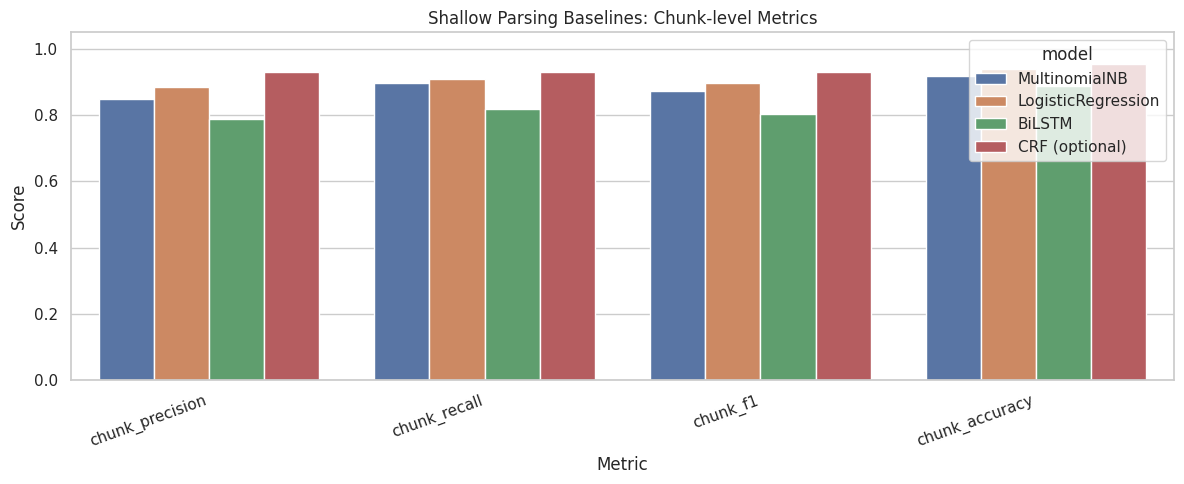

In [15]:
# Final model comparison table + graphs
rows = [
    {"model": "MultinomialNB", **nb_results},
    {"model": "LogisticRegression", **lr_results},
    {"model": "BiLSTM", **nn_results},
]

if "crf_results" in globals():
    rows.append({"model": "CRF (optional)", **crf_results})

results_df = pd.DataFrame(rows).set_index("model")
display(results_df.round(4))

plot_cols = [c for c in ["chunk_precision", "chunk_recall", "chunk_f1", "chunk_accuracy"] if c in results_df.columns]
plot_df = results_df[plot_cols].reset_index().melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1.05)
plt.title("Shallow Parsing Baselines: Chunk-level Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Extended Metric Comparison (Like Main Notebook)

This section builds side-by-side tables and plots for all available models across token-level and chunk-level metrics.

Run all previous cells first.

Token-level metrics:


,token_accuracy,token_precision_macro,token_recall_macro,token_f1_macro,token_precision_weighted,token_recall_weighted,token_f1_weighted
model,,,,,,,
MultinomialNB,0.9167,0.4890,0.4809,0.4815,0.9164,0.9167,0.9159
LogisticRegression,0.9388,0.6641,0.6078,0.6269,0.9379,0.9388,0.9381
BiLSTM,0.8882,0.4631,0.4213,0.4311,0.8813,0.8882,0.8834
CRF (optional),NaN,NaN,NaN,NaN,NaN,NaN,NaN


Chunk-level metrics:


,chunk_precision,chunk_recall,chunk_f1,chunk_accuracy
model,,,,
MultinomialNB,0.8496,0.8969,0.8726,0.9167
LogisticRegression,0.8853,0.9101,0.8975,0.9388
BiLSTM,0.7874,0.8182,0.8025,0.8882
CRF (optional),0.9314,0.9301,0.9307,0.9548


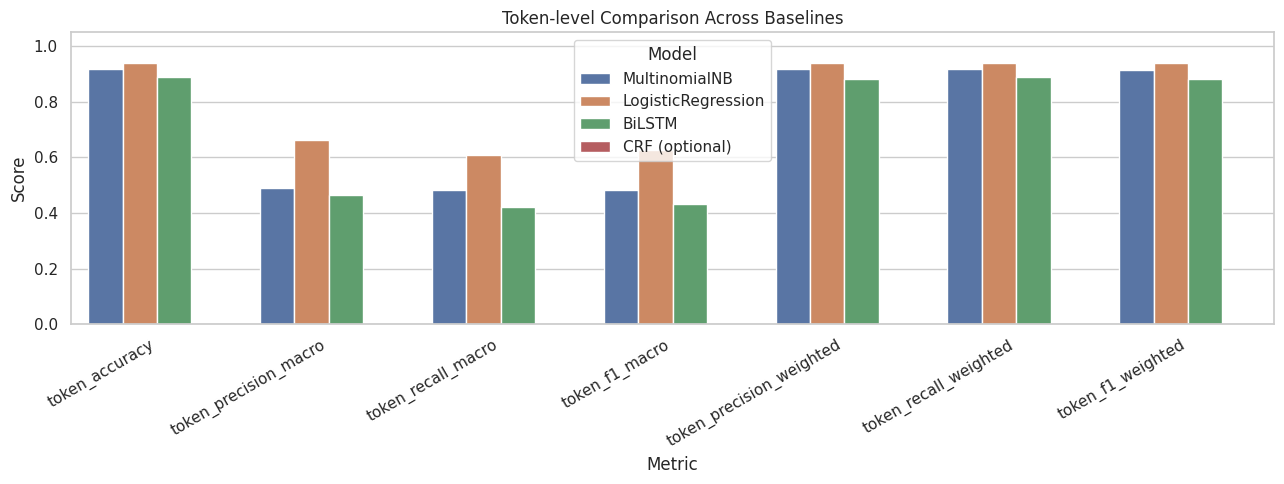

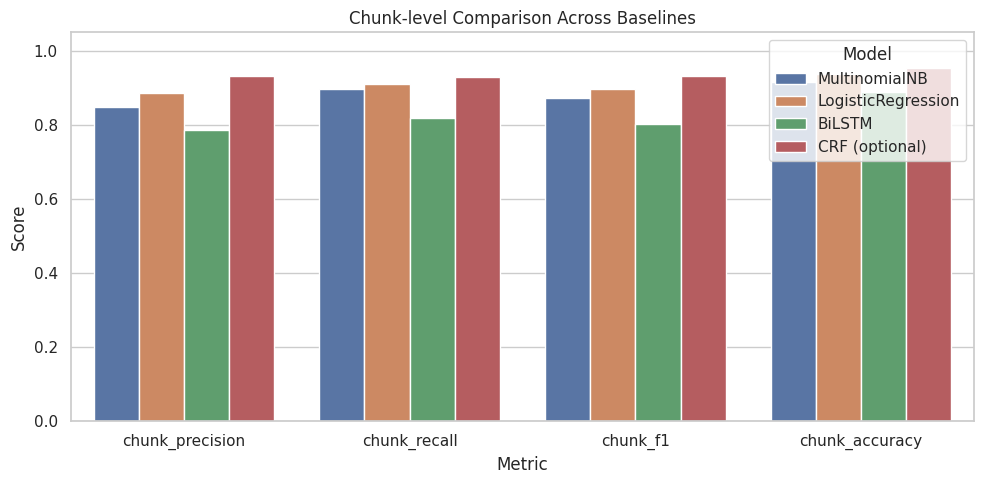

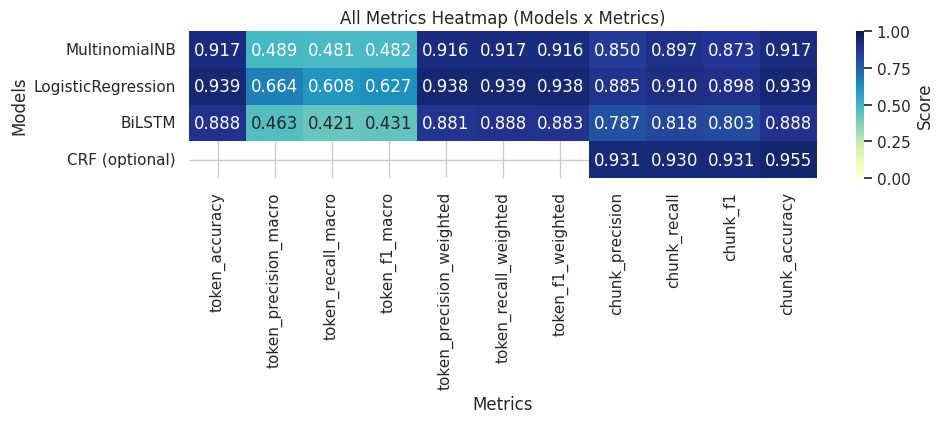

Model ranking by chunk_f1:


,chunk_f1,rank
model,,
CRF (optional),0.930735,1
LogisticRegression,0.897544,2
MultinomialNB,0.872609,3
BiLSTM,0.802508,4


In [16]:
# Extended comparison: all metrics + visualizations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

required_vars = ["nb_results", "lr_results", "nn_results"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError("Run previous model cells first. Missing: " + ", ".join(missing_vars))

rows = [
    {"model": "MultinomialNB", **nb_results},
    {"model": "LogisticRegression", **lr_results},
    {"model": "BiLSTM", **nn_results},
]
if "crf_results" in globals():
    rows.append({"model": "CRF (optional)", **crf_results})

all_metrics_df = pd.DataFrame(rows).set_index("model")

token_metric_cols = [
    "token_accuracy",
    "token_precision_macro", "token_recall_macro", "token_f1_macro",
    "token_precision_weighted", "token_recall_weighted", "token_f1_weighted",
]
chunk_metric_cols = ["chunk_precision", "chunk_recall", "chunk_f1", "chunk_accuracy"]

token_available = [c for c in token_metric_cols if c in all_metrics_df.columns]
chunk_available = [c for c in chunk_metric_cols if c in all_metrics_df.columns]

print("Token-level metrics:")
display(all_metrics_df[token_available].round(4))

print("Chunk-level metrics:")
display(all_metrics_df[chunk_available].round(4))

# Long-format tables for plotting
token_plot_df = all_metrics_df[token_available].reset_index().melt(
    id_vars="model", var_name="metric", value_name="score"
 )
chunk_plot_df = all_metrics_df[chunk_available].reset_index().melt(
    id_vars="model", var_name="metric", value_name="score"
 )

sns.set_theme(style="whitegrid")

# 1) Token-level grouped bar chart
plt.figure(figsize=(13, 5))
sns.barplot(data=token_plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1.05)
plt.title("Token-level Comparison Across Baselines")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 2) Chunk-level grouped bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=chunk_plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1.05)
plt.title("Chunk-level Comparison Across Baselines")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 3) Heatmap for quick comparison
heatmap_cols = token_available + chunk_available
plt.figure(figsize=(max(10, len(heatmap_cols) * 0.8), 2 + len(all_metrics_df) * 0.6))
sns.heatmap(
    all_metrics_df[heatmap_cols],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.0, vmax=1.0,
    cbar_kws={"label": "Score"},
)
plt.title("All Metrics Heatmap (Models x Metrics)")
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

# 4) Rank by chunk F1 (if available)
if "chunk_f1" in all_metrics_df.columns:
    rank_df = all_metrics_df[["chunk_f1"]].sort_values("chunk_f1", ascending=False).copy()
    rank_df["rank"] = range(1, len(rank_df) + 1)
    print("Model ranking by chunk_f1:")
    display(rank_df)

In [17]:
# Extended insight block: best model, gains, and error reduction
required = ["all_metrics_df"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("Run extended comparison first. Missing: " + ", ".join(missing))

if "chunk_f1" not in all_metrics_df.columns:
    raise RuntimeError("chunk_f1 not available. Run model evaluation cells first.")

rank = all_metrics_df.sort_values("chunk_f1", ascending=False).copy()
best_model = rank.index[0]
best_f1 = float(rank.iloc[0]["chunk_f1"])

summary_rows = []
for model_name, row in rank.iterrows():
    f1_val = float(row["chunk_f1"])

    acc_val = float(row["chunk_accuracy"]) if "chunk_accuracy" in row else float("nan")
    err = 1 - f1_val
    summary_rows.append({
        "model": model_name,
        "chunk_f1": f1_val,
        "chunk_accuracy": acc_val,
        "error_rate": err,
        "f1_gap_to_best": best_f1 - f1_val,
    })

insight_df = pd.DataFrame(summary_rows).set_index("model")

# Compare against Logistic Regression as a practical baseline
if "LogisticRegression" in insight_df.index:
    lr_f1 = float(insight_df.loc["LogisticRegression", "chunk_f1"])

    insight_df["f1_gain_vs_logreg"] = insight_df["chunk_f1"] - lr_f1
    lr_error = 1 - lr_f1
    insight_df["error_reduction_vs_logreg_pct"] = 100 * (
        lr_error - insight_df["error_rate"]
    ) / lr_error

display(insight_df.round(4))

print(f"Best model by chunk_f1: {best_model} ({best_f1:.4f})")

,chunk_f1,chunk_accuracy,error_rate,f1_gap_to_best,f1_gain_vs_logreg,error_reduction_vs_logreg_pct
model,,,,,,
CRF (optional),0.9307,0.9548,0.0693,0.0000,0.0332,32.3954
LogisticRegression,0.8975,0.9388,0.1025,0.0332,0.0000,0.0000
MultinomialNB,0.8726,0.9167,0.1274,0.0581,-0.0249,-24.3377
BiLSTM,0.8025,0.8882,0.1975,0.1282,-0.0950,-92.7575


Best model by chunk_f1: CRF (optional) (0.9307)
